In [18]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

In [19]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

 1. Load Data with Augmentation

In [ ]:
from pathlib import Path

train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=20, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory('../../data/train', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse')
val_gen = val_datagen.flow_from_directory('../../data/val', target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse')

Found 93 images belonging to 5 classes.
Found 25 images belonging to 5 classes.


In [21]:
train_gen.class_indices.keys()

dict_keys(['ben_afflek', 'elton_john', 'jerry_seinfeld', 'madonna', 'mindy_kaling'])

2. Build Model (Transfer Learning)

In [22]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
base_model.trainable = False 

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(len(train_gen.class_indices), activation='softmax')
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

3. Train and Save

In [23]:
model.fit(train_gen, validation_data=val_gen, epochs=10) # Cambié a 10 epocas para mejorar la precision
model.save('celebrity_model.h5')

Epoch 1/10


2026-05-05 00:46:48.037797: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2026-05-05 00:46:49.490860: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2026-05-05 00:46:49.613880: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node AssignAddVariableOp_2.


3/3 [==============================] - ETA: 0s - loss: 2.0961 - accuracy: 0.1290

2026-05-05 00:46:50.824622: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype int32
	 [[{{node Placeholder/_0}}]]
2026-05-05 00:46:51.179590: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


3/3 [==============================] - 4s 791ms/step - loss: 2.0961 - accuracy: 0.1290 - val_loss: 1.8211 - val_accuracy: 0.1200
Epoch 2/10
3/3 [==============================] - 1s 191ms/step - loss: 1.6763 - accuracy: 0.2796 - val_loss: 1.5619 - val_accuracy: 0.2800
Epoch 3/10
3/3 [==============================] - 1s 199ms/step - loss: 1.4209 - accuracy: 0.3871 - val_loss: 1.3522 - val_accuracy: 0.3600
Epoch 4/10
3/3 [==============================] - 1s 200ms/step - loss: 1.1406 - accuracy: 0.5699 - val_loss: 1.1854 - val_accuracy: 0.5200
Epoch 5/10
3/3 [==============================] - 1s 277ms/step - loss: 0.9583 - accuracy: 0.5914 - val_loss: 1.0749 - val_accuracy: 0.4800
Epoch 6/10
3/3 [==============================] - 1s 213ms/step - loss: 0.8029 - accuracy: 0.7204 - val_loss: 0.9821 - val_accuracy: 0.6000
Epoch 7/10
3/3 [==============================] - 1s 199ms/step - loss: 0.6770 - accuracy: 0.7849 - val_loss: 0.9045 - val_accuracy: 0.6400
Epoch 8/10
3/3 [===============

Store class names for prediction

In [24]:
class_names = list(train_gen.class_indices.keys())
print("Classes identified:", class_names)

Classes identified: ['ben_afflek', 'elton_john', 'jerry_seinfeld', 'madonna', 'mindy_kaling']


Testing

2026-05-05 00:46:59.481160: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 1s/step


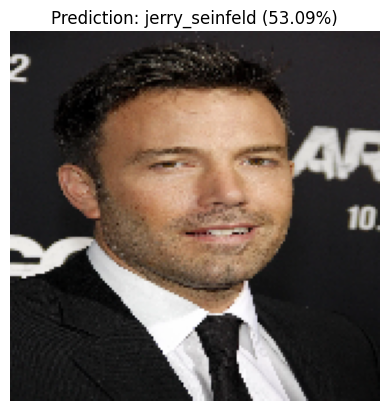

2026-05-05 00:47:02.275860: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 1s/step


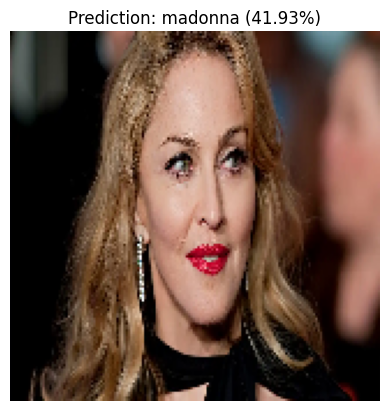

2026-05-05 00:47:04.667756: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 989ms/step


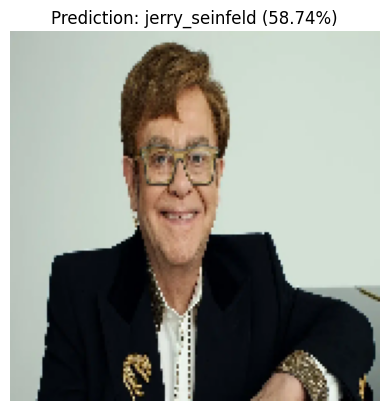

2026-05-05 00:47:07.024713: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 1s/step


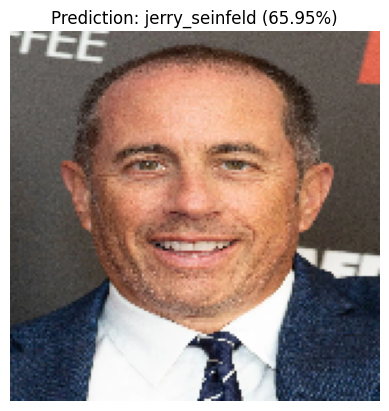

2026-05-05 00:47:09.510106: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


1/1 [==============================] - 1s 1s/step


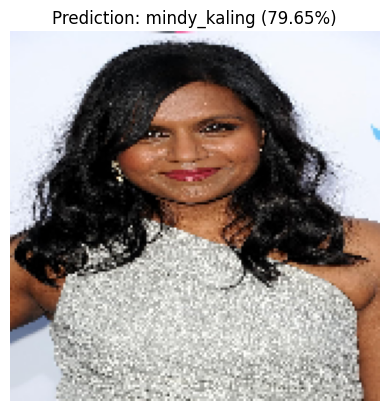

In [25]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_celebrity(img_path, model_path='celebrity_model.h5'):
    # Load model and image
    model = tf.keras.models.load_model(model_path)
    img = image.load_img(img_path, target_size=(160, 160))
    
    # Pre-process
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0) # Create batch axis

    # Predict
    predictions = model.predict(img_array)
    score = np.max(predictions)
    class_idx = np.argmax(predictions)
    
    # Display
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[class_idx]} ({100 * score:.2f}%)")
    plt.axis('off')
    plt.show()

# Usage:
predict_celebrity('Ben-Affleck.webp')
predict_celebrity('Madonna.webp')
predict_celebrity('Elton-John.webp')
predict_celebrity('Jerry-Seinfeld.webp')
predict_celebrity('Mindy-Kaling.jpg')